# 10 — Long-sequence QC, transfer patterns, and 32-sensor views

This notebook audits the first **11 long moving recordings** without modifying any raw file.

It answers four questions:

1. Are the 11 runs technically usable enough to begin a reproducible cleaning pass?
2. How random and spatially broad were the six newest trajectories?
3. What did each of the 32 sensors contribute to the frozen mint-versus-lavender identity score?
4. Is there early descriptive evidence of directional carryover when moving from mint to lavender or lavender to mint?

> **Important scope:** the source masks below are protocol-based approximate geometry, not image-measured ground truth. Transfer events repeat within recordings and are not independent trials. The results are therefore exploratory evidence, not a causal claim about physical odor transfer.


In [1]:
from __future__ import annotations

# Keep incompatible roaming-site NumPy packages out of this notebook kernel.
import sys
import site
from pathlib import Path
_user_site = site.getusersitepackages()
if _user_site in sys.path:
    sys.path.remove(_user_site)

import hashlib
import math
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.patches import Polygon
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.max_columns", 30)
plt.style.use("seaborn-v0_8-whitegrid")

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "experiments").exists():
    ROOT = ROOT.parent
assert (ROOT / "experiments").exists(), f"Repository root not found from {Path.cwd()}"

IDENTITY_MODEL_PATH = ROOT / "experiments" / "classifier" / "mint-lavender-ambient-pilot-01" / "frozen-models" / "mint-lavender-ambient-v1" / "model.joblib"
MINT_TEMPORAL_MODEL_PATH = ROOT / "experiments" / "classifier" / "mint-identity-pilot-01" / "frozen-models" / "temporal-mint-seeker-v1" / "model.joblib"
LAVENDER_TEMPORAL_MODEL_PATH = ROOT / "experiments" / "classifier" / "mint-lavender-ambient-pilot-01" / "frozen-models" / "temporal-lavender-seeker-v1" / "model.joblib"
EXPECTED_IDENTITY_SHA256 = "73d292015272a6fe69ee0bd2ce35f8fd85769068eb6b213b9acaa5ebb5e08b83"
EXPECTED_MINT_TEMPORAL_SHA256 = "7a3c3a6e078073f9e0c7e92ba7c3ec91ac0a04f64a12e6bb2f646f60cc4cb2b2"
EXPECTED_LAVENDER_TEMPORAL_SHA256 = "c11d837492b30c2d0c824826c3819749756a73a9698c1992f54ef9d7ff65228a"

PAPER_SIZE_CM = 26.5
PAPER_X_ORIGIN = 40.0
PAPER_Y_ORIGIN = 46.5
PHYSICAL_LAG_S = 2.0
MAX_POSE_GAP_S = 1.5
HEIGHT_RANGE_CM = (1.0, 3.5)
GRID_CM = 2.0
MIN_TEMPORAL_HISTORY_S = 6.0

MINT = "#82d8ad"
LAVENDER = "#c5a3e6"
NAVY = "#0b1f45"
EARLY = "#2ca25f"
MIDDLE = "#ffd92f"
LATE = "#d73027"

SEGMENTS = {
    # July protocol geometry carried forward from Notebook 09.
    "horizontal": ((4.75, 13.25), (21.75, 13.25), 3.0),
    "caret_left": ((4.75, 21.5), (11.25, 5.0), 3.0),
    "caret_right": ((15.25, 5.0), (21.75, 21.5), 3.0),
    "inverted_left": ((4.75, 5.0), (11.25, 21.5), 3.0),
    "inverted_right": ((15.25, 21.5), (21.75, 5.0), 3.0),
    # August geometry is approximate from the recorded 2 cm × 27.7 cm protocol.
    "x_backslash": ((3.5, 3.5), (23.0, 23.0), 2.0),
    "x_slash": ((3.5, 23.0), (23.0, 3.5), 2.0),
    "aug_inverted_left": ((3.5, 3.5), (11.25, 23.0), 2.0),
    "aug_inverted_right": ((23.0, 3.5), (15.25, 23.0), 2.0),
    "parallel_top": ((4.75, 7.0), (21.75, 7.0), 2.0),
    "parallel_bottom": ((4.75, 19.75), (21.75, 19.75), 2.0),
}

JULY = ROOT / "experiments" / "long-sequence" / "2026-07-30_batch-01" / "runs"
AUGUST = ROOT / "experiments" / "long-sequence" / "2026-08-03_batch-01" / "runs"

RUN_SPECS = [
    dict(session="cyranose_reading_pose_session_20260730_152754", path=JULY, title="Jul 30 · mint horizontal", mint=["horizontal"], lavender=[]),
    dict(session="cyranose_reading_pose_session_20260730_153631", path=JULY, title="Jul 30 · ^ M-left / L-right", mint=["caret_left"], lavender=["caret_right"]),
    dict(session="cyranose_reading_pose_session_20260730_154848", path=JULY, title="Jul 30 · ^ L-left / M-right", mint=["caret_right"], lavender=["caret_left"]),
    dict(session="cyranose_reading_pose_session_20260730_161358", path=JULY, title="Jul 30 · lavender horizontal", mint=[], lavender=["horizontal"]),
    dict(session="cyranose_reading_pose_session_20260730_163355", path=JULY, title="Jul 30 · V L-left / M-right", mint=["inverted_right"], lavender=["inverted_left"]),
    dict(session="cyranose_reading_pose_session_20260803_144217", path=AUGUST, title="Aug 03 · X M-backslash / L-slash · 01", mint=["x_backslash"], lavender=["x_slash"], newest=True),
    dict(session="cyranose_reading_pose_session_20260803_150952", path=AUGUST, title="Aug 03 · X M-backslash / L-slash · 02", mint=["x_backslash"], lavender=["x_slash"], newest=True),
    dict(session="cyranose_reading_pose_session_20260803_154420", path=AUGUST, title="Aug 03 · X L-backslash / M-slash · 03", mint=["x_slash"], lavender=["x_backslash"], newest=True),
    dict(session="cyranose_reading_pose_session_20260803_160842", path=AUGUST, title="Aug 03 · X L-backslash / M-slash · 04", mint=["x_slash"], lavender=["x_backslash"], newest=True),
    dict(session="cyranose_reading_pose_session_20260803_164023", path=AUGUST, title="Aug 03 · V L-left / M-right", mint=["aug_inverted_right"], lavender=["aug_inverted_left"], newest=True),
    dict(session="cyranose_reading_pose_session_20260803_170357", path=AUGUST, title="Aug 03 · parallel M-top / L-bottom", mint=["parallel_top"], lavender=["parallel_bottom"], newest=True),
]
for spec in RUN_SPECS:
    spec.setdefault("newest", False)
    spec["run_dir"] = spec["path"] / spec["session"]
    spec["csv"] = spec["run_dir"] / "cyranose_reading_pose.csv"
    assert spec["csv"].exists(), spec["csv"]

print(f"Repository: {ROOT}")
print(f"Runs found: {len(RUN_SPECS)}")
print(f"Newest runs: {sum(s['newest'] for s in RUN_SPECS)}")


Repository: C:\Users\dell-xps\Documents\realsense-apriltag
Runs found: 11
Newest runs: 6


In [2]:
def sha256(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


def bool_series(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.lower().isin({"true", "1", "yes"})


def l2_normalize(matrix: np.ndarray) -> np.ndarray:
    matrix = np.asarray(matrix, dtype=float)
    norm = np.linalg.norm(matrix, axis=1, keepdims=True)
    return matrix / np.where(norm > 1e-12, norm, 1.0)


def irregular_ema(times: np.ndarray, values: np.ndarray, tau_s: float) -> np.ndarray:
    out = np.empty_like(values, dtype=float)
    out[0] = values[0]
    for i in range(1, len(values)):
        dt = max(0.0, float(times[i] - times[i - 1]))
        alpha = 1.0 - math.exp(-dt / tau_s)
        out[i] = out[i - 1] + alpha * (values[i] - out[i - 1])
    return out


def interpolate_vectors(times: np.ndarray, values: np.ndarray, query_times: np.ndarray) -> np.ndarray:
    return np.column_stack([
        np.interp(query_times, times, values[:, sensor_index])
        for sensor_index in range(values.shape[1])
    ])


def build_temporal_features(times: np.ndarray, values: np.ndarray, indices: np.ndarray, config: dict) -> np.ndarray:
    current = values[indices]
    parts = [current]
    for lookback_s in config["lookbacks"]:
        previous = interpolate_vectors(times, values, times[indices] - lookback_s)
        parts.append(current - previous)
    for tau_s in config["ema_taus"]:
        ema = irregular_ema(times, values, tau_s)
        parts.append(current - ema[indices])
    return np.column_stack(parts)


def aligned_state_probability(model, features: np.ndarray, state_order: list[str]) -> np.ndarray:
    raw = model.predict_proba(features)
    result = np.zeros((len(features), len(state_order)), dtype=float)
    for source_column, state in enumerate(model.classes_):
        result[:, state_order.index(state)] = raw[:, source_column]
    return result


def point_segment_distance(x: np.ndarray, y: np.ndarray, segment) -> np.ndarray:
    (x1, y1), (x2, y2), _ = segment
    px = np.asarray(x, float)
    py = np.asarray(y, float)
    vx, vy = x2 - x1, y2 - y1
    denom = vx * vx + vy * vy
    t = np.clip(((px - x1) * vx + (py - y1) * vy) / denom, 0.0, 1.0)
    return np.hypot(px - (x1 + t * vx), py - (y1 + t * vy))


def segment_mask(frame: pd.DataFrame, names: list[str], margin_cm: float = 0.0) -> np.ndarray:
    if not names:
        return np.zeros(len(frame), dtype=bool)
    x = frame["paper_x_cm"].to_numpy(float)
    y = frame["paper_y_cm"].to_numpy(float)
    mask = np.zeros(len(frame), dtype=bool)
    for name in names:
        segment = SEGMENTS[name]
        mask |= point_segment_distance(x, y, segment) <= segment[2] / 2.0 + margin_cm
    return mask


def label_sources(frame: pd.DataFrame, spec: dict, margin_cm: float = 1.0) -> np.ndarray:
    mint = segment_mask(frame, spec["mint"], margin_cm)
    lavender = segment_mask(frame, spec["lavender"], margin_cm)
    label = np.full(len(frame), "background", dtype=object)
    label[mint] = "mint"
    label[lavender] = "lavender"
    label[mint & lavender] = "overlap"
    return label


def segment_polygon(segment):
    (x1, y1), (x2, y2), width = segment
    vx, vy = x2 - x1, y2 - y1
    length = math.hypot(vx, vy)
    px, py = -(vy / length) * width / 2.0, (vx / length) * width / 2.0
    return np.array([[x1 + px, y1 + py], [x2 + px, y2 + py], [x2 - px, y2 - py], [x1 - px, y1 - py]])


def draw_sources(ax, spec: dict):
    for odor, color in [("mint", MINT), ("lavender", LAVENDER)]:
        for name in spec[odor]:
            ax.add_patch(Polygon(segment_polygon(SEGMENTS[name]), closed=True, facecolor=color, edgecolor=color, alpha=0.20, linewidth=1.5))


def isolated_spike_rows(resistance: np.ndarray, flag: np.ndarray, deviation_pct: float = 10.0, neighbor_pct: float = 3.0) -> np.ndarray:
    """Flag an isolated acquisition row only when adjacent rows agree and the center sharply departs."""
    if len(resistance) < 3:
        return np.array([], dtype=int)
    midpoint = (resistance[:-2] + resistance[2:]) / 2.0
    scale = np.maximum(np.abs(midpoint), 1e-9)
    center_deviation = 100.0 * np.abs(resistance[1:-1] - midpoint) / scale
    neighbor_disagreement = 100.0 * np.abs(resistance[2:] - resistance[:-2]) / scale
    bad = (center_deviation > deviation_pct) & (neighbor_disagreement < neighbor_pct)
    rows = np.flatnonzero(np.any(bad, axis=1)) + 1
    return rows[flag[rows] == 2]


def spearman_abs(a: np.ndarray, b: np.ndarray) -> float:
    if len(a) < 3 or np.nanstd(a) == 0 or np.nanstd(b) == 0:
        return np.nan
    return abs(pd.Series(a).corr(pd.Series(b), method="spearman"))


def read_and_score_run(spec: dict, identity_bundle: dict, mint_temporal_bundle: dict, lavender_temporal_bundle: dict) -> dict:
    frame = pd.read_csv(spec["csv"])
    resistance_cols = [f"pcnose_S{i}_kohm" for i in range(1, 33)]
    resistance = frame[resistance_cols].apply(pd.to_numeric, errors="coerce").to_numpy(float)
    flag = pd.to_numeric(frame["pcnose_flag"], errors="coerce").fillna(-1).to_numpy(int)
    host_time = pd.to_datetime(frame["pcnose_sample_time_estimate_utc"], errors="coerce", utc=True)
    assert host_time.notna().all()
    host_elapsed = (host_time - host_time.iloc[0]).dt.total_seconds().to_numpy(float)

    baseline_mask = flag == 1
    if baseline_mask.sum() < 2:
        baseline_mask = np.arange(len(frame)) < min(20, len(frame))
    baseline_rows = resistance[baseline_mask]
    baseline = np.nanmedian(baseline_rows[len(baseline_rows) // 2 :], axis=0)
    response = 100.0 * (resistance - baseline) / np.maximum(np.abs(baseline), 1e-12)
    # Causal 3-row median: neutralizes isolated acquisition spikes without looking into the future.
    smooth_response = pd.DataFrame(response).rolling(3, min_periods=1).median().to_numpy(float)

    minimum_history_s = max(
        float(mint_temporal_bundle["minimum_history_s"]),
        float(lavender_temporal_bundle["minimum_history_s"]),
    )
    temporal_idx = np.flatnonzero(
        (flag == 2) & np.isfinite(smooth_response).all(axis=1) & (host_elapsed >= minimum_history_s)
    )
    X = smooth_response[temporal_idx]
    X_unit = l2_normalize(X)

    presence = identity_bundle["presence_model"]
    identity = identity_bundle["identity_model"]
    odor_score = presence.predict_proba(X)[:, 1]
    mint_share = identity.predict_proba(X_unit)[:, 1]

    scaler = identity.named_steps["scale"]
    logistic = identity.named_steps["model"]
    standardized = scaler.transform(X_unit)
    contributions = standardized * logistic.coef_[0]
    reconstructed_logit = float(logistic.intercept_[0]) + contributions.sum(axis=1)
    np.testing.assert_allclose(reconstructed_logit, identity.decision_function(X_unit), rtol=1e-9, atol=1e-9)

    mint_features = build_temporal_features(
        host_elapsed, response, temporal_idx, mint_temporal_bundle["feature_config"]
    )
    mint_order = list(mint_temporal_bundle["state_order"])
    mint_states = aligned_state_probability(
        mint_temporal_bundle["temporal_model"], mint_features, mint_order
    )
    active_mint_raw = mint_states[:, mint_order.index("active_mint")]
    fading_mint = mint_states[:, mint_order.index("mint_recovery")]

    lavender_features = build_temporal_features(
        host_elapsed, response, temporal_idx, lavender_temporal_bundle["feature_config"]
    )
    lavender_order = list(lavender_temporal_bundle["state_order"])
    lavender_states = aligned_state_probability(
        lavender_temporal_bundle["temporal_model"], lavender_features, lavender_order
    )
    active_lavender_raw = lavender_states[:, lavender_order.index("active_lavender")]
    fading_lavender = lavender_states[:, lavender_order.index("lavender_recovery")]

    active_mint = np.where(odor_score >= 0.5, active_mint_raw, 0.0) * mint_share
    active_lavender = np.where(odor_score >= 0.5, active_lavender_raw, 0.0) * (1.0 - mint_share)

    scored = pd.DataFrame({
        "score_pos": np.arange(len(temporal_idx)),
        "frame_index": temporal_idx,
        "host_elapsed_s": host_elapsed[temporal_idx],
        "pose_elapsed_s": pd.to_numeric(frame.loc[temporal_idx, "pose_elapsed_s"], errors="coerce").to_numpy(float),
        "odor_score": odor_score,
        "mint_share": mint_share,
        "lavender_share": 1.0 - mint_share,
        "active_mint": active_mint,
        "active_lavender": active_lavender,
        "fading_mint": fading_mint,
        "fading_lavender": fading_lavender,
    })

    pose_valid = bool_series(frame["snout_position_valid"]) if "snout_position_valid" in frame else pd.Series(True, index=frame.index)
    pose = pd.DataFrame({
        "elapsed_s": pd.to_numeric(frame["pose_elapsed_s"], errors="coerce"),
        "desk_x_cm": pd.to_numeric(frame["snout_desk_x_cm"], errors="coerce"),
        "desk_y_cm": pd.to_numeric(frame["snout_desk_y_cm"], errors="coerce"),
        "height_cm": -pd.to_numeric(frame["snout_desk_z_cm"], errors="coerce"),
        "valid": pose_valid,
    })
    pose = pose.loc[pose["valid"] & np.isfinite(pose[["elapsed_s", "desk_x_cm", "desk_y_cm", "height_cm"]]).all(axis=1)].sort_values("elapsed_s")

    aligned_rows = []
    if len(pose):
        pose_t = pose["elapsed_s"].to_numpy(float)
        for row in scored.itertuples(index=False):
            target = row.pose_elapsed_s - PHYSICAL_LAG_S
            if not np.isfinite(target):
                continue
            k = int(np.argmin(np.abs(pose_t - target)))
            gap = abs(float(pose_t[k] - target))
            if gap > MAX_POSE_GAP_S:
                continue
            p = pose.iloc[k]
            aligned_rows.append({
                **row._asdict(),
                "paper_x_cm": PAPER_X_ORIGIN - float(p.desk_x_cm),
                "paper_y_cm": PAPER_Y_ORIGIN - float(p.desk_y_cm),
                "height_cm": float(p.height_cm),
                "pose_gap_s": gap,
            })
    aligned = pd.DataFrame(aligned_rows)
    if len(aligned):
        aligned = aligned[
            aligned["paper_x_cm"].between(0, PAPER_SIZE_CM)
            & aligned["paper_y_cm"].between(0, PAPER_SIZE_CM)
        ].copy()
        aligned["strict_height"] = aligned["height_cm"].between(*HEIGHT_RANGE_CM)
        aligned["source_label"] = label_sources(aligned, spec, 1.0)

    trajectory_mask = (flag == 2) & pose_valid.to_numpy()
    trajectory = pd.DataFrame({
        "time_s": host_elapsed[trajectory_mask],
        "paper_x_cm": PAPER_X_ORIGIN - pd.to_numeric(frame.loc[trajectory_mask, "snout_desk_x_cm"], errors="coerce").to_numpy(float),
        "paper_y_cm": PAPER_Y_ORIGIN - pd.to_numeric(frame.loc[trajectory_mask, "snout_desk_y_cm"], errors="coerce").to_numpy(float),
        "height_cm": -pd.to_numeric(frame.loc[trajectory_mask, "snout_desk_z_cm"], errors="coerce").to_numpy(float),
    }).dropna()
    trajectory = trajectory[
        trajectory["paper_x_cm"].between(0, PAPER_SIZE_CM)
        & trajectory["paper_y_cm"].between(0, PAPER_SIZE_CM)
    ].copy()

    strict = aligned[aligned["strict_height"]].copy() if len(aligned) else aligned.copy()
    cells_2cm = 0
    if len(strict):
        cells_2cm = strict.assign(
            cx=(strict["paper_x_cm"] / GRID_CM).astype(int),
            cy=(strict["paper_y_cm"] / GRID_CM).astype(int),
        )[["cx", "cy"]].drop_duplicates().shape[0]

    sync_valid = bool_series(frame["pose_alignment_valid"])
    sync_abs = pd.to_numeric(frame["abs_pose_minus_pcnose_ms"], errors="coerce")
    sensor_complete = np.isfinite(resistance).all(axis=1)
    spikes = isolated_spike_rows(resistance, flag)
    dt = np.diff(host_elapsed[np.isfinite(host_elapsed)])
    strict_pct = 100.0 * len(strict) / max(len(aligned), 1)
    duration_min = (np.nanmax(host_elapsed) - np.nanmin(host_elapsed)) / 60.0

    notes = []
    if duration_min < 9.5:
        notes.append("shorter than 10 min; host timing remains valid")
    if strict_pct < 75:
        notes.append("height coverage caution")
    if len(spikes):
        notes.append(f"{len(spikes)} isolated sensor row flagged")
    analysis_ready = sensor_complete.mean() == 1.0 and sync_valid.mean() >= 0.99 and len(strict) >= 100 and cells_2cm >= 100
    if not notes:
        notes.append("no material QC caveat")

    return {
        "spec": spec,
        "frame": frame,
        "flag": flag,
        "host_elapsed": host_elapsed,
        "response": response,
        "smooth_response": smooth_response,
        "scored": scored,
        "contributions": contributions,
        "aligned": aligned,
        "strict": strict,
        "trajectory": trajectory,
        "spike_rows": spikes,
        "qc": {
            "session": spec["session"].replace("cyranose_reading_pose_session_", ""),
            "layout": spec["title"],
            "duration_min": duration_min,
            "rows": len(frame),
            "flag2_rows": int((flag == 2).sum()),
            "sensor_complete_pct": 100.0 * sensor_complete.mean(),
            "sync_valid_pct": 100.0 * sync_valid.mean(),
            "sync_p95_ms": float(sync_abs.quantile(0.95)),
            "snout_valid_pct": 100.0 * pose_valid.mean(),
            "max_read_interval_s": float(np.nanmax(dt)),
            "causal_paper_rows": len(aligned),
            "strict_height_rows": len(strict),
            "strict_height_pct": strict_pct,
            "grid_cells_2cm": cells_2cm,
            "isolated_spike_rows": len(spikes),
            "abs_rho_time_x": spearman_abs(trajectory["time_s"].to_numpy(), trajectory["paper_x_cm"].to_numpy()),
            "abs_rho_time_y": spearman_abs(trajectory["time_s"].to_numpy(), trajectory["paper_y_cm"].to_numpy()),
            "analysis_ready": analysis_ready,
            "qc_note": "; ".join(notes),
        },
    }


In [3]:
assert sha256(IDENTITY_MODEL_PATH) == EXPECTED_IDENTITY_SHA256, "Frozen identity model checksum changed."
assert sha256(MINT_TEMPORAL_MODEL_PATH) == EXPECTED_MINT_TEMPORAL_SHA256, "Frozen mint temporal model checksum changed."
assert sha256(LAVENDER_TEMPORAL_MODEL_PATH) == EXPECTED_LAVENDER_TEMPORAL_SHA256, "Frozen lavender temporal model checksum changed."
identity_bundle = joblib.load(IDENTITY_MODEL_PATH)
mint_temporal_bundle = joblib.load(MINT_TEMPORAL_MODEL_PATH)
lavender_temporal_bundle = joblib.load(LAVENDER_TEMPORAL_MODEL_PATH)

runs = [
    read_and_score_run(spec, identity_bundle, mint_temporal_bundle, lavender_temporal_bundle)
    for spec in RUN_SPECS
]
qc = pd.DataFrame([run["qc"] for run in runs])

qc_view = qc[[
    "session", "duration_min", "rows", "sensor_complete_pct", "sync_valid_pct", "sync_p95_ms",
    "snout_valid_pct", "causal_paper_rows", "strict_height_rows", "strict_height_pct",
    "grid_cells_2cm", "isolated_spike_rows", "analysis_ready", "qc_note"
]].copy()
qc_view.columns = [
    "session", "minutes", "rows", "32D finite %", "sync %", "sync p95 ms",
    "snout pose %", "causal paper rows", "height-filter rows", "height-filter %",
    "2 cm cells", "spike rows", "ready", "QC note"
]
display(qc_view.round({
    "minutes": 2, "32D finite %": 1, "sync %": 1, "sync p95 ms": 1,
    "snout pose %": 1, "height-filter %": 1
}))

ready_count = int(qc["analysis_ready"].sum())
height_caution = qc.loc[qc["strict_height_pct"] < 75, "session"].tolist()
spike_runs = qc.loc[qc["isolated_spike_rows"] > 0, "session"].tolist()
short_runs = qc.loc[qc["duration_min"] < 9.5, "session"].tolist()

display(Markdown(
    f"""### QC verdict

**{ready_count}/{len(qc)} runs pass the same analysis-readiness gate.** Every CSV has complete 32-channel rows and at least 99% accepted smell–pose matches. The July recordings that predate the waypoint timing fix are shorter than ten wall-clock minutes, but their stored host timestamps, odor rows, and pose alignments remain usable.

- Height-coverage caution: {", ".join(height_caution) if height_caution else "none"}
- Isolated sensor acquisition event: {", ".join(spike_runs) if spike_runs else "none"}
- Shorter than the intended 10 minutes: {", ".join(short_runs) if short_runs else "none"}

The raw files stay untouched. The analysis uses a **causal** three-row median to neutralize an isolated spike, never interpolates sensor values, rejects pose matches farther than {MAX_POSE_GAP_S:.1f} s, applies the fixed {PHYSICAL_LAG_S:.1f} s physical response correction, and labels height-qualified rows separately.
"""
))

display(Markdown(
    """### Proposed first-pass cleaning contract

1. Preserve every raw CSV and MP4 exactly as recorded.
2. Use host midpoint time as the common clock; keep the stored nearest-frame QC fields.
3. Estimate the 32-sensor baseline from the latter half of flag-1 rows.
4. Convert each sensor to percentage change from that run's baseline.
5. Flag isolated one-row acquisition spikes; use a trailing three-row median for model input.
6. Apply the frozen six-second history requirement and the fixed two-second physical response correction.
7. Reject pose gaps over 1.5 seconds, out-of-paper coordinates, and rows outside the predeclared 1–3.5 cm height range for strict spatial claims.
8. Retain both a permissive table and a strict spatial-analysis table, with explicit exclusion reasons.
"""
))


,session,minutes,rows,32D finite %,sync %,sync p95 ms,snout pose %,causal paper rows,height-filter rows,height-filter %,2 cm cells,spike rows,ready,QC note
0,20260730_152754,6.54,706,100.0,100.0,85.3,99.0,562,547,97.3,160,0,True,shorter than 10 min; host timing remains valid
1,20260730_153631,6.83,737,100.0,100.0,95.2,97.7,665,583,87.7,167,0,True,shorter than 10 min; host timing remains valid
2,20260730_154848,7.03,759,100.0,100.0,92.9,91.4,633,541,85.5,158,0,True,shorter than 10 min; host timing remains valid
3,20260730_161358,7.68,829,100.0,100.0,88.8,93.5,699,681,97.4,171,0,True,shorter than 10 min; host timing remains valid
4,20260730_163355,10.32,1114,100.0,100.0,89.7,97.6,964,886,91.9,182,0,True,no material QC caveat
5,20260803_144217,10.36,1118,100.0,100.0,91.4,95.9,1000,542,54.2,158,0,True,height coverage caution
6,20260803_150952,10.51,1134,100.0,100.0,95.7,96.0,1053,839,79.7,169,0,True,no material QC caveat
7,20260803_154420,10.95,1181,100.0,100.0,95.1,94.0,1090,929,85.2,174,1,True,1 isolated sensor row flagged
8,20260803_160842,10.78,1163,100.0,100.0,95.4,95.3,1066,861,80.8,170,0,True,no material QC caveat
9,20260803_164023,11.17,1205,100.0,100.0,94.8,97.5,1124,1034,92.0,182,0,True,no material QC caveat


### QC verdict

**11/11 runs pass the same analysis-readiness gate.** Every CSV has complete 32-channel rows and at least 99% accepted smell–pose matches. The July recordings that predate the waypoint timing fix are shorter than ten wall-clock minutes, but their stored host timestamps, odor rows, and pose alignments remain usable.

- Height-coverage caution: 20260803_144217
- Isolated sensor acquisition event: 20260803_154420
- Shorter than the intended 10 minutes: 20260730_152754, 20260730_153631, 20260730_154848, 20260730_161358

The raw files stay untouched. The analysis uses a **causal** three-row median to neutralize an isolated spike, never interpolates sensor values, rejects pose matches farther than 1.5 s, applies the fixed 2.0 s physical response correction, and labels height-qualified rows separately.


### Proposed first-pass cleaning contract

1. Preserve every raw CSV and MP4 exactly as recorded.
2. Use host midpoint time as the common clock; keep the stored nearest-frame QC fields.
3. Estimate the 32-sensor baseline from the latter half of flag-1 rows.
4. Convert each sensor to percentage change from that run's baseline.
5. Flag isolated one-row acquisition spikes; use a trailing three-row median for model input.
6. Apply the frozen six-second history requirement and the fixed two-second physical response correction.
7. Reject pose gaps over 1.5 seconds, out-of-paper coordinates, and rows outside the predeclared 1–3.5 cm height range for strict spatial claims.
8. Retain both a permissive table and a strict spatial-analysis table, with explicit exclusion reasons.


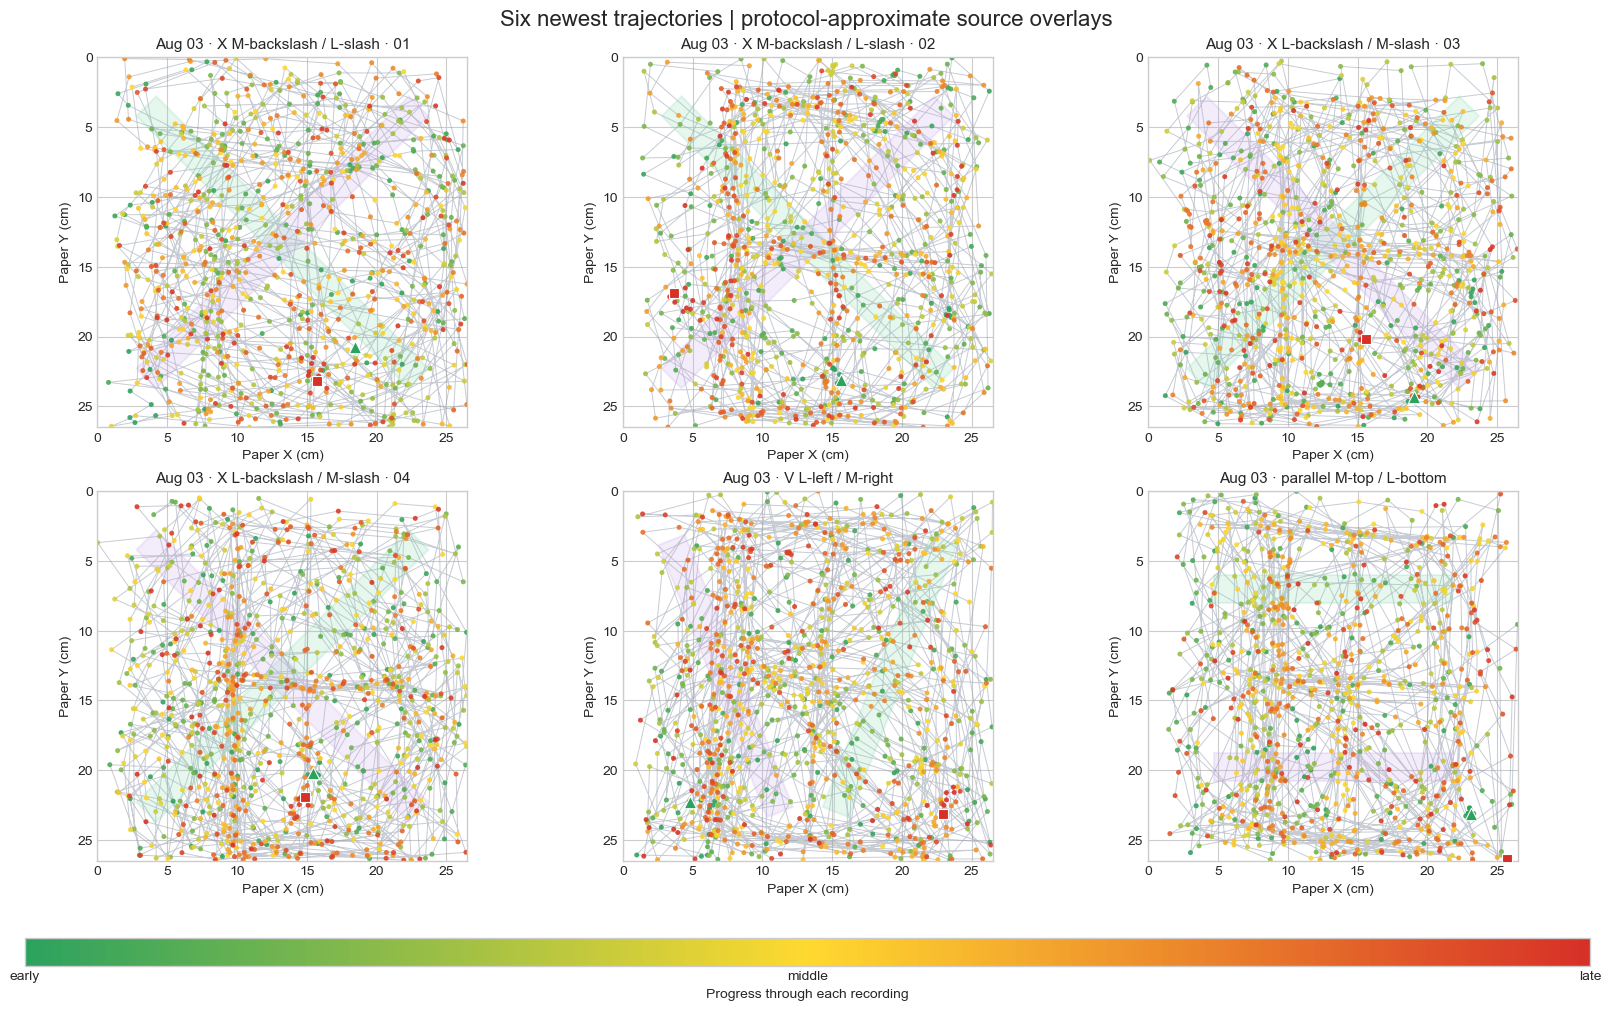

,session,grid_cells_2cm,strict_height_pct,max |time-axis rank correlation|
5,20260803_144217,158,54.200,0.060
6,20260803_150952,169,79.677,0.127
7,20260803_154420,174,85.229,0.035
8,20260803_160842,170,80.769,0.066
9,20260803_164023,182,91.993,0.041
10,20260803_170357,163,86.455,0.150


**How to read this:** green is early, yellow is the middle, and red is late. A truly random path is not being claimed; this is a coverage and confounding diagnostic. The six runs cover **158–182 distinct 2 cm cells**, and their largest absolute time-versus-axis rank correlation is **0.150**. That is substantially less monotone than the earlier sequential rasters.

The translucent green and purple strips are approximate protocol geometry only. They help orientation but should not be treated as image-registered boundaries.


In [4]:
new_runs = [run for run in runs if run["spec"]["newest"]]
time_cmap = mcolors.LinearSegmentedColormap.from_list("early_middle_late", [EARLY, MIDDLE, LATE])

fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
for ax, run in zip(axes.flat, new_runs):
    traj = run["trajectory"].sort_values("time_s")
    progress = (traj["time_s"] - traj["time_s"].min()) / max(traj["time_s"].max() - traj["time_s"].min(), 1e-9)
    ax.plot(traj["paper_x_cm"], traj["paper_y_cm"], color="#9098a8", linewidth=0.7, alpha=0.50, zorder=1)
    ax.scatter(
        traj["paper_x_cm"], traj["paper_y_cm"], c=progress, cmap=time_cmap,
        vmin=0, vmax=1, s=13, linewidths=0, alpha=0.90, zorder=2
    )
    draw_sources(ax, run["spec"])
    ax.scatter(traj.iloc[0]["paper_x_cm"], traj.iloc[0]["paper_y_cm"], marker="^", s=80, color=EARLY, edgecolor="white", linewidth=0.8, zorder=4)
    ax.scatter(traj.iloc[-1]["paper_x_cm"], traj.iloc[-1]["paper_y_cm"], marker="s", s=62, color=LATE, edgecolor="white", linewidth=0.8, zorder=4)
    ax.set_title(run["spec"]["title"], fontsize=11)
    ax.set_xlim(0, PAPER_SIZE_CM)
    ax.set_ylim(PAPER_SIZE_CM, 0)
    ax.set_aspect("equal")
    ax.set_xlabel("Paper X (cm)")
    ax.set_ylabel("Paper Y (cm)")

sm = plt.cm.ScalarMappable(norm=mcolors.Normalize(0, 1), cmap=time_cmap)
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.045, pad=0.05, aspect=55)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(["early", "middle", "late"])
cbar.set_label("Progress through each recording")
fig.suptitle("Six newest trajectories | protocol-approximate source overlays", fontsize=16)
plt.show()

randomness_view = qc.loc[qc["session"].str.startswith("20260803"), [
    "session", "grid_cells_2cm", "abs_rho_time_x", "abs_rho_time_y", "strict_height_pct"
]].copy()
randomness_view["max |time-axis rank correlation|"] = randomness_view[["abs_rho_time_x", "abs_rho_time_y"]].max(axis=1)
randomness_view = randomness_view.drop(columns=["abs_rho_time_x", "abs_rho_time_y"])
display(randomness_view.round(3))

display(Markdown(
    f"""**How to read this:** green is early, yellow is the middle, and red is late. A truly random path is not being claimed; this is a coverage and confounding diagnostic. The six runs cover **{int(randomness_view["grid_cells_2cm"].min())}–{int(randomness_view["grid_cells_2cm"].max())} distinct 2 cm cells**, and their largest absolute time-versus-axis rank correlation is **{randomness_view["max |time-axis rank correlation|"].max():.3f}**. That is substantially less monotone than the earlier sequential rasters.

The translucent green and purple strips are approximate protocol geometry only. They help orientation but should not be treated as image-registered boundaries.
"""
))


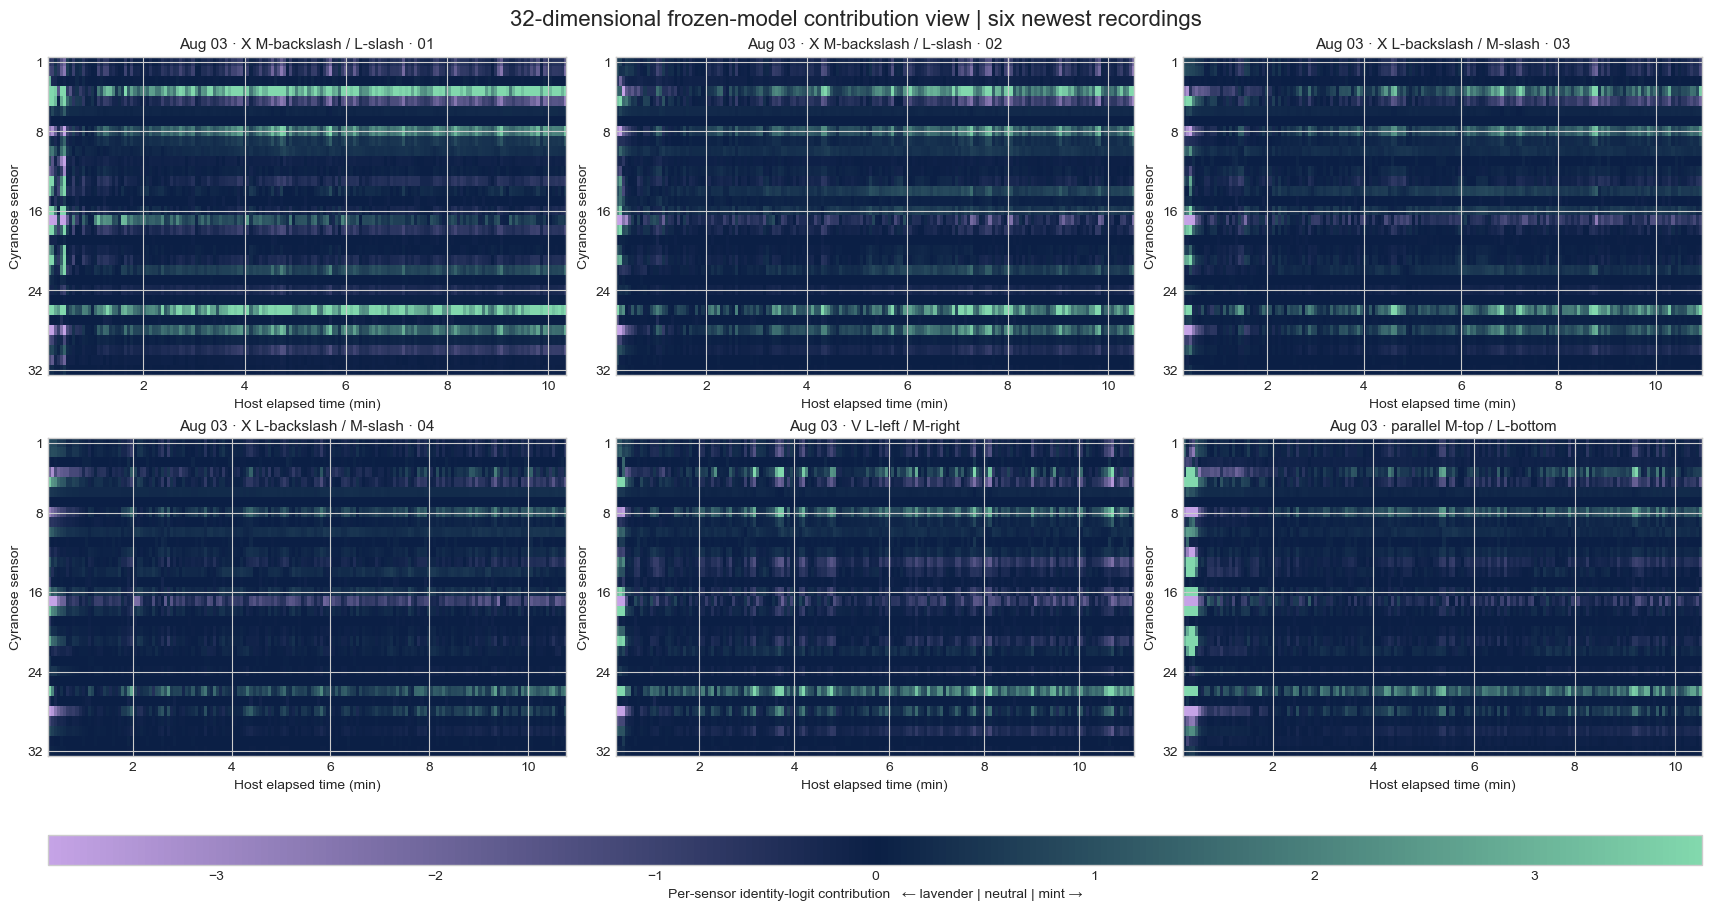

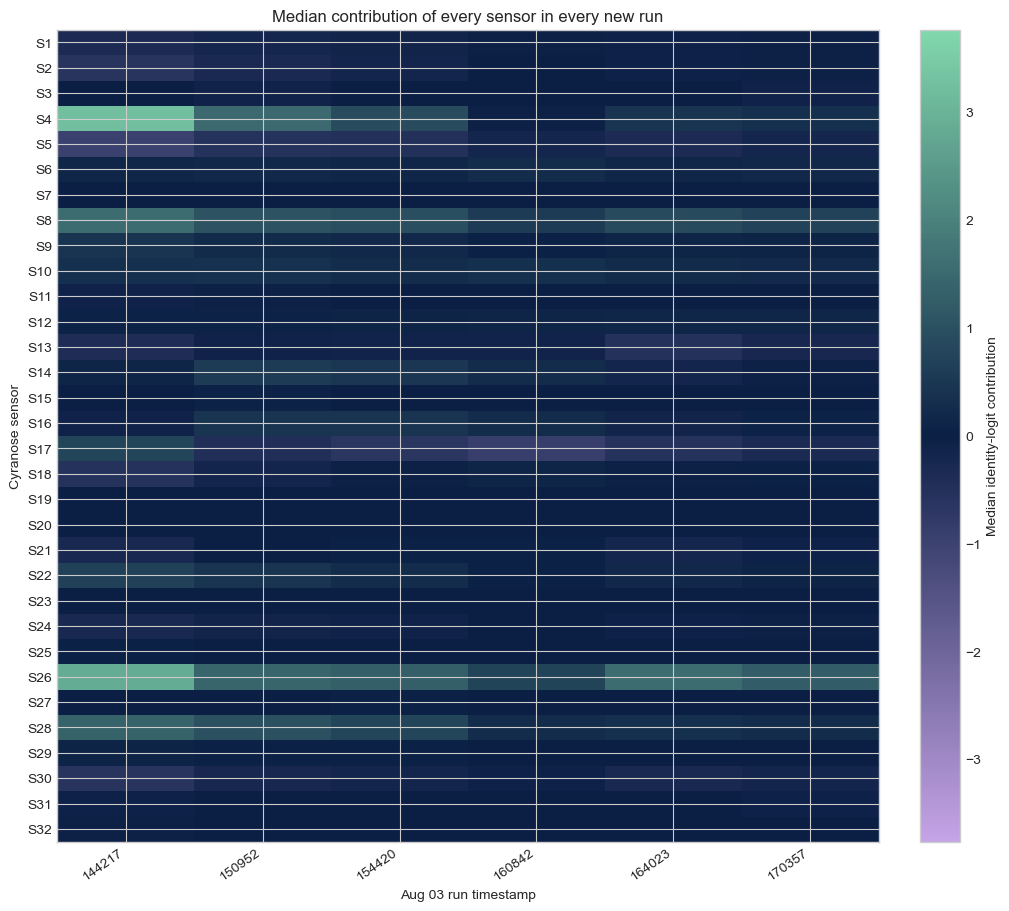

,sensor,median_abs_contribution,median_signed_contribution
25,S26,1.4780,1.4133
7,S8,0.9793,0.9262
3,S4,0.9688,0.7562
27,S28,0.7195,0.6098
16,S17,0.6721,-0.4335
4,S5,0.5475,-0.4412
15,S16,0.3149,0.2091
1,S2,0.3038,-0.1846
9,S10,0.2996,0.2996
13,S14,0.2950,0.1973


### ELI5: what “32-dimensional” means here

Each horizontal row is one physical Cyranose sensor, so no sensor is collapsed away. The frozen identity classifier first normalizes the full 32-value response, standardizes it using its training data, and forms a weighted sum.

- **Mint green:** this sensor, at that moment, pushes the frozen identity score toward mint.
- **Lavender purple:** it pushes toward lavender.
- **Dark blue:** little identity evidence from that sensor at that moment.

These are exact additive contributions to the classifier's mint-versus-lavender logit. They are **not 32 independent odor probabilities**, and they are not concentration measurements. Large continuous green regions can therefore reveal persistent mint-like sensor history or model bias as well as current physical mint exposure.


In [5]:
def time_bin_matrix(times: np.ndarray, values: np.ndarray, n_bins: int = 170):
    edges = np.linspace(float(times.min()), float(times.max()), n_bins + 1)
    index = np.clip(np.digitize(times, edges) - 1, 0, n_bins - 1)
    binned = np.full((n_bins, values.shape[1]), np.nan)
    for b in range(n_bins):
        present = index == b
        if present.any():
            binned[b] = np.nanmedian(values[present], axis=0)
    # Fill gaps only for visual continuity after real rows have been aggregated.
    return pd.DataFrame(binned).interpolate(limit_direction="both").to_numpy(), edges


all_contrib = np.vstack([run["contributions"] for run in new_runs])
limit = float(np.nanquantile(np.abs(all_contrib), 0.99))
identity_cmap = mcolors.LinearSegmentedColormap.from_list("lavender_neutral_mint", [LAVENDER, NAVY, MINT])
identity_norm = mcolors.TwoSlopeNorm(vmin=-limit, vcenter=0.0, vmax=limit)

fig, axes = plt.subplots(2, 3, figsize=(17, 9), constrained_layout=True)
for ax, run in zip(axes.flat, new_runs):
    t = run["scored"]["host_elapsed_s"].to_numpy(float)
    binned, edges = time_bin_matrix(t, run["contributions"])
    im = ax.imshow(
        binned.T, aspect="auto", origin="upper", cmap=identity_cmap, norm=identity_norm,
        extent=[edges[0] / 60.0, edges[-1] / 60.0, 32.5, 0.5], interpolation="nearest"
    )
    ax.set_title(run["spec"]["title"], fontsize=11)
    ax.set_xlabel("Host elapsed time (min)")
    ax.set_ylabel("Cyranose sensor")
    ax.set_yticks([1, 8, 16, 24, 32])

cbar = fig.colorbar(im, ax=axes, orientation="horizontal", fraction=0.045, pad=0.06, aspect=55)
cbar.set_label("Per-sensor identity-logit contribution   ← lavender | neutral | mint →")
fig.suptitle("32-dimensional frozen-model contribution view | six newest recordings", fontsize=16)
plt.show()

aggregate = np.column_stack([np.nanmedian(run["contributions"], axis=0) for run in new_runs])
fig, ax = plt.subplots(figsize=(10, 9), constrained_layout=True)
im2 = ax.imshow(aggregate, aspect="auto", origin="upper", cmap=identity_cmap, norm=identity_norm, interpolation="nearest")
ax.set_yticks(np.arange(32))
ax.set_yticklabels([f"S{i}" for i in range(1, 33)])
ax.set_xticks(np.arange(len(new_runs)))
ax.set_xticklabels([run["spec"]["session"][-6:] for run in new_runs], rotation=35, ha="right")
ax.set_xlabel("Aug 03 run timestamp")
ax.set_ylabel("Cyranose sensor")
ax.set_title("Median contribution of every sensor in every new run")
fig.colorbar(im2, ax=ax, label="Median identity-logit contribution")
plt.show()

sensor_strength = pd.DataFrame({
    "sensor": [f"S{i}" for i in range(1, 33)],
    "median_abs_contribution": np.nanmedian(np.abs(all_contrib), axis=0),
    "median_signed_contribution": np.nanmedian(all_contrib, axis=0),
}).sort_values("median_abs_contribution", ascending=False)
display(sensor_strength.head(10).round(4))

display(Markdown(
    """### ELI5: what “32-dimensional” means here

Each horizontal row is one physical Cyranose sensor, so no sensor is collapsed away. The frozen identity classifier first normalizes the full 32-value response, standardizes it using its training data, and forms a weighted sum.

- **Mint green:** this sensor, at that moment, pushes the frozen identity score toward mint.
- **Lavender purple:** it pushes toward lavender.
- **Dark blue:** little identity evidence from that sensor at that moment.

These are exact additive contributions to the classifier's mint-versus-lavender logit. They are **not 32 independent odor probabilities**, and they are not concentration measurements. Large continuous green regions can therefore reveal persistent mint-like sensor history or model bias as well as current physical mint exposure.
"""
))


,direction,events,runs,target_identity_share,previous_identity_share,target_active,previous_active,odor_presence
0,lavender → mint,288,9,0.984,0.016,0.042,0.000,1.0
1,mint → lavender,320,9,0.029,0.971,0.000,0.161,1.0


**Run-level median sensitivity check** — each recording contributes once per direction:

,direction,contributing_runs,target_identity_share,target_active,previous_active
0,lavender → mint,9,0.985,0.033,0.000
1,mint → lavender,9,0.031,0.000,0.256


**Geometry sensitivity:** the descriptive direction is checked at three reasonable source-mask margins.

,source margin cm,direction,events,runs,run-median target identity,run-median target active,run-median previous active
0,0.5,lavender → mint,184,9,0.987,0.014,0.000
1,0.5,mint → lavender,202,9,0.028,0.000,0.407
2,1.0,lavender → mint,288,9,0.985,0.033,0.000
3,1.0,mint → lavender,320,9,0.031,0.000,0.256
4,1.5,lavender → mint,375,9,0.986,0.038,0.000
5,1.5,mint → lavender,417,9,0.032,0.000,0.235


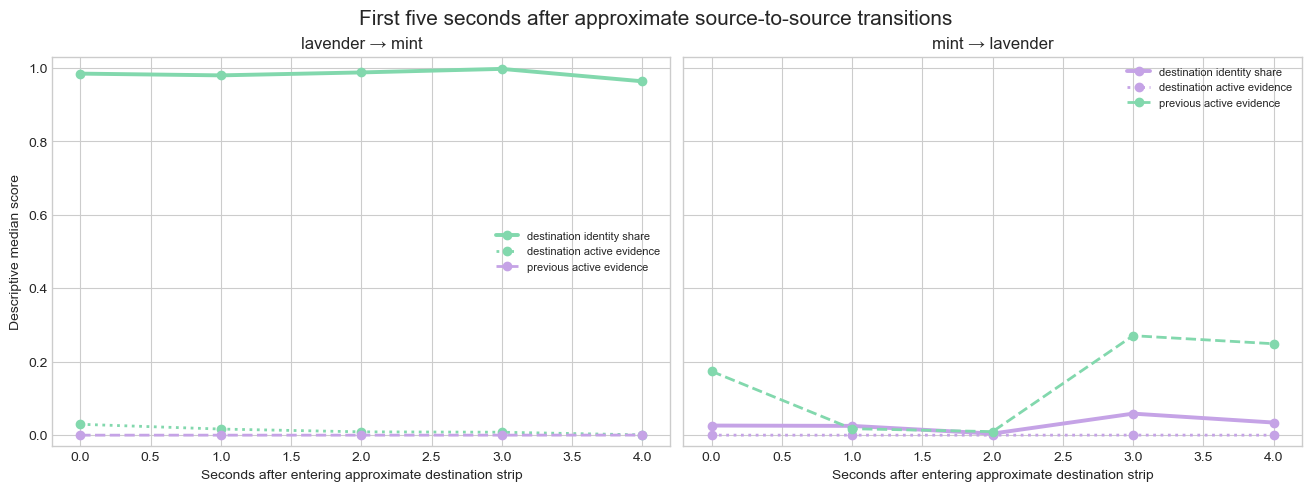

### Early directional pattern

Across repeated within-run entries, **lavender → mint** has median destination identity share **0.984**, while **mint → lavender** has median lavender destination share **0.029**. After mint → lavender, the previous mint-active score has median **0.161** during the first five seconds.

That is a strong **descriptive asymmetry consistent with mint dominance/carryover in the current pipeline**. It is not yet proof that mint molecules physically transferred into the lavender strip. The same pattern could combine sensor recovery, stronger mint loading, stationary-training session effects, frozen-model bias, and approximate source geometry. Repeated events within a run are correlated, so this notebook intentionally reports medians and margin sensitivity rather than a p-value.


In [6]:
def transfer_events_for_margin(margin_cm: float):
    event_rows = []
    profile_rows = []
    for run in runs:
        spec = run["spec"]
        if not spec["mint"] or not spec["lavender"]:
            continue
        frame = run["strict"].sort_values("host_elapsed_s").reset_index(drop=True).copy()
        if len(frame) < 3:
            continue
        frame["source_label"] = label_sources(frame, spec, margin_cm)
        labels = frame["source_label"].to_numpy(object)
        times = frame["host_elapsed_s"].to_numpy(float)
        start = 0
        while start < len(frame):
            label = labels[start]
            stop = start + 1
            while stop < len(frame) and labels[stop] == label:
                stop += 1
            # Require two readings in a source episode; center overlaps in X layouts are ignored.
            if label in {"mint", "lavender"} and stop - start >= 2:
                previous_candidates = np.flatnonzero(
                    (np.arange(len(frame)) < start)
                    & (labels != label)
                    & np.isin(labels, ["mint", "lavender"])
                    & ((times[start] - times) <= 30.0)
                )
                if len(previous_candidates):
                    previous = labels[int(previous_candidates[-1])]
                    episode = frame.iloc[start:stop].copy()
                    episode["since_entry_s"] = episode["host_elapsed_s"] - episode["host_elapsed_s"].iloc[0]
                    early = episode[episode["since_entry_s"] <= 5.0]
                    if len(early):
                        if label == "mint":
                            target_share = early["mint_share"]
                            prior_share = early["lavender_share"]
                            target_active = early["active_mint"]
                            prior_active = early["active_lavender"]
                        else:
                            target_share = early["lavender_share"]
                            prior_share = early["mint_share"]
                            target_active = early["active_lavender"]
                            prior_active = early["active_mint"]
                        direction = f"{previous} → {label}"
                        event_rows.append({
                            "session": spec["session"][-15:],
                            "direction": direction,
                            "event_time_s": times[start],
                            "n_early_rows": len(early),
                            "target_identity_share": float(target_share.median()),
                            "previous_identity_share": float(prior_share.median()),
                            "target_active": float(target_active.median()),
                            "previous_active": float(prior_active.median()),
                            "odor_presence": float(early["odor_score"].median()),
                        })
                        for _, sample in early.iterrows():
                            profile_rows.append({
                                "session": spec["session"][-15:],
                                "direction": direction,
                                "since_entry_s": float(sample["since_entry_s"]),
                                "target_identity_share": float(sample["mint_share"] if label == "mint" else sample["lavender_share"]),
                                "target_active": float(sample["active_mint"] if label == "mint" else sample["active_lavender"]),
                                "previous_active": float(sample["active_lavender"] if label == "mint" else sample["active_mint"]),
                            })
            start = stop
    return pd.DataFrame(event_rows), pd.DataFrame(profile_rows)


events, profiles = transfer_events_for_margin(1.0)
summary = events.groupby("direction").agg(
    events=("direction", "size"),
    runs=("session", "nunique"),
    target_identity_share=("target_identity_share", "median"),
    previous_identity_share=("previous_identity_share", "median"),
    target_active=("target_active", "median"),
    previous_active=("previous_active", "median"),
    odor_presence=("odor_presence", "median"),
).reset_index()
display(summary.round(3))

run_level = events.groupby(["session", "direction"], as_index=False).median(numeric_only=True)
run_level_summary = run_level.groupby("direction").agg(
    contributing_runs=("session", "nunique"),
    target_identity_share=("target_identity_share", "median"),
    target_active=("target_active", "median"),
    previous_active=("previous_active", "median"),
).reset_index()
display(Markdown("**Run-level median sensitivity check** — each recording contributes once per direction:"))
display(run_level_summary.round(3))

sensitivity_rows = []
for margin in [0.5, 1.0, 1.5]:
    margin_events, _ = transfer_events_for_margin(margin)
    per_run = margin_events.groupby(["session", "direction"], as_index=False).median(numeric_only=True)
    for direction, group in per_run.groupby("direction"):
        sensitivity_rows.append({
            "source margin cm": margin,
            "direction": direction,
            "events": int((margin_events["direction"] == direction).sum()),
            "runs": group["session"].nunique(),
            "run-median target identity": group["target_identity_share"].median(),
            "run-median target active": group["target_active"].median(),
            "run-median previous active": group["previous_active"].median(),
        })
sensitivity = pd.DataFrame(sensitivity_rows)
display(Markdown("**Geometry sensitivity:** the descriptive direction is checked at three reasonable source-mask margins."))
display(sensitivity.round(3))

if len(profiles):
    profiles["second"] = np.floor(profiles["since_entry_s"]).astype(int)
    profile_summary = profiles.groupby(["direction", "second"]).agg(
        target_identity=("target_identity_share", "median"),
        target_active=("target_active", "median"),
        previous_active=("previous_active", "median"),
    ).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True, constrained_layout=True)
    for ax, direction in zip(axes, ["lavender → mint", "mint → lavender"]):
        part = profile_summary[profile_summary["direction"] == direction]
        destination_color = MINT if direction.endswith("mint") else LAVENDER
        previous_color = LAVENDER if direction.startswith("lavender") else MINT
        ax.plot(part["second"], part["target_identity"], color=destination_color, linewidth=2.8, marker="o", label="destination identity share")
        ax.plot(part["second"], part["target_active"], color=destination_color, linewidth=2.0, linestyle=":", marker="o", label="destination active evidence")
        ax.plot(part["second"], part["previous_active"], color=previous_color, linewidth=2.0, linestyle="--", marker="o", label="previous active evidence")
        ax.set_title(direction)
        ax.set_xlabel("Seconds after entering approximate destination strip")
        ax.set_ylim(-0.03, 1.03)
        ax.legend(fontsize=8, loc="best")
    axes[0].set_ylabel("Descriptive median score")
    fig.suptitle("First five seconds after approximate source-to-source transitions", fontsize=15)
    plt.show()

lm = summary.set_index("direction")
lav_to_mint = lm.loc["lavender → mint"] if "lavender → mint" in lm.index else None
mint_to_lav = lm.loc["mint → lavender"] if "mint → lavender" in lm.index else None
if lav_to_mint is not None and mint_to_lav is not None:
    display(Markdown(
        f"""### Early directional pattern

Across repeated within-run entries, **lavender → mint** has median destination identity share **{lav_to_mint["target_identity_share"]:.3f}**, while **mint → lavender** has median lavender destination share **{mint_to_lav["target_identity_share"]:.3f}**. After mint → lavender, the previous mint-active score has median **{mint_to_lav["previous_active"]:.3f}** during the first five seconds.

That is a strong **descriptive asymmetry consistent with mint dominance/carryover in the current pipeline**. It is not yet proof that mint molecules physically transferred into the lavender strip. The same pattern could combine sensor recovery, stronger mint loading, stationary-training session effects, frozen-model bias, and approximate source geometry. Repeated events within a run are correlated, so this notebook intentionally reports medians and margin sensitivity rather than a p-value.
"""
    ))


In [7]:
max_time_axis_corr = qc.loc[qc["session"].str.startswith("20260803"), ["abs_rho_time_x", "abs_rho_time_y"]].max(axis=1).max()
min_cells = int(qc["grid_cells_2cm"].min())
max_cells = int(qc["grid_cells_2cm"].max())

display(Markdown(
    f"""## Bottom line

- **Usability:** all **{int(qc["analysis_ready"].sum())}/11** recordings are usable for a versioned first cleaning pass. Preserve the raw files and write any cleaned tables to a separate processed-data directory.
- **Spatial sampling:** the runs contain **{min_cells}–{max_cells} occupied 2 cm cells** under the strict spatial filter. The six newest paths have maximum absolute time-axis rank correlation **{max_time_axis_corr:.3f}**, supporting their use as less-predictable movement sequences.
- **Known caveats:** one Aug 03 run has lower strict-height retention; one run contains one isolated sensor acquisition event; four July runs are shorter than ten wall-clock minutes because of the retired waypoint-timing behavior.
- **32-sensor pattern:** the contribution maps expose which channels drive mint-like versus lavender-like identity over time. They also make persistent mint-like history visible instead of hiding it inside one probability.
- **Transfer pattern:** the preliminary transition analysis is directionally asymmetric and mint-dominant. Treat this as a hypothesis for the next controlled analysis, not as proof of chemical transfer.

### Recommended next data step

Before training a sequence model on all 11 runs, freeze a cleaning schema and export an auditable processed table containing: raw row index, host time, all 32 raw resistances, baseline-normalized channels, spike flag, synchronized pose gap, paper coordinates, height-pass flag, approximate source label, and exclusion reason. Then evaluate by **held-out whole recording**, never by randomly mixing rows from the same run across train and test.
"""
))


## Bottom line

- **Usability:** all **11/11** recordings are usable for a versioned first cleaning pass. Preserve the raw files and write any cleaned tables to a separate processed-data directory.
- **Spatial sampling:** the runs contain **158–182 occupied 2 cm cells** under the strict spatial filter. The six newest paths have maximum absolute time-axis rank correlation **0.150**, supporting their use as less-predictable movement sequences.
- **Known caveats:** one Aug 03 run has lower strict-height retention; one run contains one isolated sensor acquisition event; four July runs are shorter than ten wall-clock minutes because of the retired waypoint-timing behavior.
- **32-sensor pattern:** the contribution maps expose which channels drive mint-like versus lavender-like identity over time. They also make persistent mint-like history visible instead of hiding it inside one probability.
- **Transfer pattern:** the preliminary transition analysis is directionally asymmetric and mint-dominant. Treat this as a hypothesis for the next controlled analysis, not as proof of chemical transfer.

### Recommended next data step

Before training a sequence model on all 11 runs, freeze a cleaning schema and export an auditable processed table containing: raw row index, host time, all 32 raw resistances, baseline-normalized channels, spike flag, synchronized pose gap, paper coordinates, height-pass flag, approximate source label, and exclusion reason. Then evaluate by **held-out whole recording**, never by randomly mixing rows from the same run across train and test.
